In [1]:
!pip install -q transformers torchvision albumentations timm wandb

In [2]:
import torch

print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: no disponible, se usara CPU")

CUDA disponible: True
GPU: NVIDIA GeForce RTX 5060 Ti


In [3]:
!git clone https://github.com/tangsanli5201/DeepPCB.git

fatal: la ruta de destino 'DeepPCB' ya existe y no es un directorio vacío.


In [4]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset


class DeepPCBDataset(Dataset):
    def __init__(self, root_dir, split_file):
        self.root_dir = root_dir

        with open(split_file, "r") as f:
            self.samples = [line.strip().split() for line in f.readlines()]

        self.classes = ["open", "short", "mousebite", "spur", "copper", "pin-hole"]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_rel_path, ann_rel_path = self.samples[idx]

        img_path = os.path.join(
            self.root_dir,
            img_rel_path.replace(".jpg", "_test.jpg")
        )
        ann_path = os.path.join(self.root_dir, ann_rel_path)

        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size

        annotations = []

        if os.path.exists(ann_path):
            with open(ann_path, "r") as f:
                for line in f:
                    parts = line.strip().split()

                    if len(parts) < 5:
                        continue

                    xmin, ymin, xmax, ymax = map(float, parts[0:4])
                    category_id = int(parts[4])

                    if category_id < 0 or category_id >= len(self.classes):
                        continue

                    xmin = max(0.0, min(xmin, img_w))
                    ymin = max(0.0, min(ymin, img_h))
                    xmax = max(0.0, min(xmax, img_w))
                    ymax = max(0.0, min(ymax, img_h))

                    xmin, xmax = sorted([xmin, xmax])
                    ymin, ymax = sorted([ymin, ymax])

                    width = xmax - xmin
                    height = ymax - ymin

                    if width < 1 or height < 1:
                        continue

                    annotations.append({
                        "bbox": [xmin, ymin, width, height],
                        "category_id": category_id,
                        "area": width * height,
                        "iscrowd": 0,
                    })

        target = {
            "image_id": idx,
            "annotations": annotations,
        }

        return image, target

In [5]:
ROOT_DIR = "DeepPCB/PCBData"
SPLIT_FILE = "DeepPCB/PCBData/trainval.txt"

dataset = DeepPCBDataset(ROOT_DIR, SPLIT_FILE)

print("Samples:", len(dataset))
print("Clases:", dataset.classes)

Samples: 1000
Clases: ['open', 'short', 'mousebite', 'spur', 'copper', 'pin-hole']


In [6]:
img, target = dataset[0]

print(img.size)
print(target)

(640, 640)
{'image_id': 0, 'annotations': [{'bbox': [409.0, 394.0, 26.0, 28.0], 'category_id': 3, 'area': 728.0, 'iscrowd': 0}, {'bbox': [275.0, 383.0, 44.0, 34.0], 'category_id': 3, 'area': 1496.0, 'iscrowd': 0}, {'bbox': [8.0, 163.0, 28.0, 28.0], 'category_id': 4, 'area': 784.0, 'iscrowd': 0}, {'bbox': [244.0, 151.0, 26.0, 31.0], 'category_id': 5, 'area': 806.0, 'iscrowd': 0}, {'bbox': [476.0, 460.0, 26.0, 21.0], 'category_id': 4, 'area': 546.0, 'iscrowd': 0}]}


In [7]:
import torch
from torch.utils.data import random_split

# Fijar semilla para reproducibilidad
torch.manual_seed(42)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 700
Val size: 150
Test size: 150


In [8]:
import torch
from transformers import DetrForObjectDetection, DetrImageProcessor

# Processor
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

# Mapeo de clases (6 defectos)
id2label = {
    0: "open",
    1: "short",
    2: "mousebite",
    3: "spur",
    4: "copper",
    5: "pin-hole",
}

label2id = {v: k for k, v in id2label.items()}

# Modelo con 6 clases
model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=6,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Modelo listo en:", device)

/home/seba/miniconda3/envs/visionComputerII/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 5119.69it/s]
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |             

Modelo listo en: cuda


In [9]:
from torch.utils.data import DataLoader

batch_size = 4
num_workers = 2
pin_memory = torch.cuda.is_available()

def collate_fn(batch):
    images = [item[0] for item in batch]
    annotations = [item[1] for item in batch]

    encoding = processor(
        images=images,
        annotations=annotations,
        return_tensors="pt"
    )

    return encoding

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    collate_fn=collate_fn,
)

print("Collate y loaders listos")

Collate y loaders listos


In [10]:
import csv
import json
import math
import os
from copy import deepcopy
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import torch

os.environ["WANDB_MODE"] = "offline"

try:
    import wandb
    use_wandb = True
except ImportError:
    wandb = None
    use_wandb = False

# Configs originales para corrida larga / overnight:
# experiment_configs = [
#     {
#         "name": "lr_3e5_backbone_5e6",
#         "lr": 3e-5,
#         "lr_backbone": 5e-6,
#         "epochs": 60,
#         "weight_decay": 1e-4,
#         "max_grad_norm": 0.1,
#     },
#     {
#         "name": "lr_5e5_backbone_5e6",
#         "lr": 5e-5,
#         "lr_backbone": 5e-6,
#         "epochs": 60,
#         "weight_decay": 1e-4,
#         "max_grad_norm": 0.1,
#     },
#     {
#         "name": "lr_1e4_backbone_1e5",
#         "lr": 1e-4,
#         "lr_backbone": 1e-5,
#         "epochs": 60,
#         "weight_decay": 1e-4,
#         "max_grad_norm": 0.1,
#     },
#     {
#         "name": "lr_2e4_backbone_1e5",
#         "lr": 2e-4,
#         "lr_backbone": 1e-5,
#         "epochs": 60,
#         "weight_decay": 1e-4,
#         "max_grad_norm": 0.1,
#     },
# ]

# Barrido nocturno centrado en la mejor zona detectada por la corrida rapida.
experiment_configs = [
    {
        "name": "overnight_lr_3e5_bb_1e5",
        "lr": 3e-5,
        "lr_backbone": 1e-5,
        "epochs": 30,
        "weight_decay": 1e-4,
        "max_grad_norm": 0.1,
    },
    {
        "name": "overnight_lr_5e5_bb_1e5",
        "lr": 5e-5,
        "lr_backbone": 1e-5,
        "epochs": 30,
        "weight_decay": 1e-4,
        "max_grad_norm": 0.1,
    },
    {
        "name": "overnight_lr_2e5_bb_1e5",
        "lr": 2e-5,
        "lr_backbone": 1e-5,
        "epochs": 30,
        "weight_decay": 1e-4,
        "max_grad_norm": 0.1,
    },
    {
        "name": "overnight_lr_3e5_bb_8e6",
        "lr": 3e-5,
        "lr_backbone": 8e-6,
        "epochs": 30,
        "weight_decay": 1e-4,
        "max_grad_norm": 0.1,
    },
    {
        "name": "overnight_lr_3e5_bb_1p5e5",
        "lr": 3e-5,
        "lr_backbone": 1.5e-5,
        "epochs": 30,
        "weight_decay": 1e-4,
        "max_grad_norm": 0.1,
    },
    {
        "name": "overnight_lr_3e5_bb_1e5_wd_5e5",
        "lr": 3e-5,
        "lr_backbone": 1e-5,
        "epochs": 30,
        "weight_decay": 5e-5,
        "max_grad_norm": 0.1,
    },
    {
        "name": "overnight_lr_3e5_bb_1e5_wd_2e4",
        "lr": 3e-5,
        "lr_backbone": 1e-5,
        "epochs": 30,
        "weight_decay": 2e-4,
        "max_grad_norm": 0.1,
    },
    {
        "name": "overnight_lr_5e5_bb_5e6",
        "lr": 5e-5,
        "lr_backbone": 5e-6,
        "epochs": 30,
        "weight_decay": 1e-4,
        "max_grad_norm": 0.1,
    },
]

suite_name = f"detr_deeppcb_suite_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
suite_dir = Path("runs") / suite_name
wandb_root_dir = suite_dir / "wandb"
suite_dir.mkdir(parents=True, exist_ok=True)
wandb_root_dir.mkdir(parents=True, exist_ok=True)

all_histories = {}
all_run_dirs = {}
all_summaries = []
global_best_val_loss = float("inf")
global_best_state_dict = None
best_experiment_name = None
best_run_dir = None

for experiment in experiment_configs:
    exp_name = experiment["name"]
    run_name = f"{suite_name}_{exp_name}"
    save_dir = suite_dir / exp_name
    wandb_dir = wandb_root_dir / exp_name
    save_dir.mkdir(parents=True, exist_ok=True)
    wandb_dir.mkdir(parents=True, exist_ok=True)
    os.environ["WANDB_DIR"] = str(wandb_dir.resolve())

    lr = experiment["lr"]
    lr_backbone = experiment["lr_backbone"]
    epochs = experiment["epochs"]
    weight_decay = experiment["weight_decay"]
    max_grad_norm = experiment["max_grad_norm"]

    print(f"\n===== Iniciando experimento: {exp_name} =====")

    model = DetrForObjectDetection.from_pretrained(
        "facebook/detr-resnet-50",
        num_labels=6,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )
    model.to(device)

    optimizer = torch.optim.AdamW(
        [
            {
                "params": [p for n, p in model.named_parameters() if p.requires_grad and "backbone" not in n],
                "lr": lr,
            },
            {
                "params": [p for n, p in model.named_parameters() if p.requires_grad and "backbone" in n],
                "lr": lr_backbone,
            },
        ],
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    config = {
        "experiment_name": exp_name,
        "learning_rate": lr,
        "learning_rate_backbone": lr_backbone,
        "batch_size": batch_size,
        "epochs": epochs,
        "optimizer": "AdamW",
        "weight_decay": weight_decay,
        "max_grad_norm": max_grad_norm,
        "num_workers": num_workers,
        "train_size": len(train_dataset),
        "val_size": len(val_dataset),
        "test_size": len(test_dataset),
        "classes": dataset.classes,
    }

    history = {
        "train_loss": [],
        "val_loss": [],
        "lr_main": [],
        "lr_backbone": [],
    }

    if use_wandb:
        wandb_run = wandb.init(
            project="deeppcb-detr",
            name=run_name,
            config=config,
            dir=str(wandb_dir.resolve()),
            mode="offline",
            reinit=True,
        )
    else:
        wandb_run = None

    best_val_loss = float("inf")
    best_state_dict = None
    metrics_csv_path = save_dir / "history.csv"

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        processed_train_batches = 0

        for batch in train_loader:
            pixel_values = batch["pixel_values"].to(device)
            pixel_mask = batch.get("pixel_mask")
            if pixel_mask is not None:
                pixel_mask = pixel_mask.to(device)

            labels = [
                {k: v.to(device) for k, v in t.items()}
                for t in batch["labels"]
            ]

            optimizer.zero_grad(set_to_none=True)

            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                labels=labels,
            )
            loss = outputs.loss

            if not torch.isfinite(loss):
                print(f"{exp_name} | Epoch {epoch+1}: batch de train omitido por loss no finita")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            total_train_loss += loss.item()
            processed_train_batches += 1

        avg_train_loss = total_train_loss / processed_train_batches if processed_train_batches > 0 else float("nan")

        model.eval()
        total_val_loss = 0.0
        processed_val_batches = 0

        with torch.no_grad():
            for batch in val_loader:
                pixel_values = batch["pixel_values"].to(device)
                pixel_mask = batch.get("pixel_mask")
                if pixel_mask is not None:
                    pixel_mask = pixel_mask.to(device)

                labels = [
                    {k: v.to(device) for k, v in t.items()}
                    for t in batch["labels"]
                ]

                outputs = model(
                    pixel_values=pixel_values,
                    pixel_mask=pixel_mask,
                    labels=labels,
                )
                loss = outputs.loss

                if not torch.isfinite(loss):
                    print(f"{exp_name} | Epoch {epoch+1}: batch de val omitido por loss no finita")
                    continue

                total_val_loss += loss.item()
                processed_val_batches += 1

        avg_val_loss = total_val_loss / processed_val_batches if processed_val_batches > 0 else float("nan")

        if math.isfinite(avg_val_loss):
            scheduler.step(avg_val_loss)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["lr_main"].append(optimizer.param_groups[0]["lr"])
        history["lr_backbone"].append(optimizer.param_groups[1]["lr"])

        epoch_metrics = {
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "lr_main": optimizer.param_groups[0]["lr"],
            "lr_backbone": optimizer.param_groups[1]["lr"],
        }

        if use_wandb:
            wandb.log(epoch_metrics)

        if math.isfinite(avg_val_loss) and avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state_dict = deepcopy(model.state_dict())
            torch.save(best_state_dict, save_dir / "model_best.pth")

        torch.save(model.state_dict(), save_dir / "model_last.pth")

        print(
            f"{exp_name} | Epoch {epoch+1}/{epochs} | "
            f"Train: {avg_train_loss:.4f} | "
            f"Val: {avg_val_loss:.4f} | "
            f"LR main: {optimizer.param_groups[0]['lr']:.2e} | "
            f"LR backbone: {optimizer.param_groups[1]['lr']:.2e}"
        )

    with metrics_csv_path.open("w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "train_loss", "val_loss", "lr_main", "lr_backbone"])
        for idx in range(len(history["train_loss"])):
            writer.writerow([
                idx + 1,
                history["train_loss"][idx],
                history["val_loss"][idx],
                history["lr_main"][idx],
                history["lr_backbone"][idx],
            ])

    with (save_dir / "history.json").open("w") as f:
        json.dump(history, f, indent=2)

    with (save_dir / "config.json").open("w") as f:
        json.dump(config, f, indent=2)

    plt.figure(figsize=(10, 5))
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"], label="Validation")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training Curve - {exp_name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / "loss_curve.png", dpi=150)
    plt.close()

    all_histories[exp_name] = history
    all_run_dirs[exp_name] = str(save_dir)
    all_summaries.append({
        "experiment_name": exp_name,
        "best_val_loss": best_val_loss,
        "run_dir": str(save_dir),
    })

    if math.isfinite(best_val_loss) and best_val_loss < global_best_val_loss:
        global_best_val_loss = best_val_loss
        global_best_state_dict = deepcopy(best_state_dict) if best_state_dict is not None else deepcopy(model.state_dict())
        best_experiment_name = exp_name
        best_run_dir = save_dir

    if use_wandb:
        wandb.finish()

plt.figure(figsize=(10, 5))
for exp_name, history in all_histories.items():
    plt.plot(history["val_loss"], label=f"{exp_name} - val")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Comparacion de Experimentos")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(suite_dir / "comparison_val_loss.png", dpi=150)
plt.close()

suite_summary = {
    "suite_name": suite_name,
    "best_experiment_name": best_experiment_name,
    "best_val_loss": global_best_val_loss,
    "best_run_dir": str(best_run_dir) if best_run_dir is not None else None,
    "experiments": all_summaries,
}

with (suite_dir / "suite_summary.json").open("w") as f:
    json.dump(suite_summary, f, indent=2)

if global_best_state_dict is not None:
    model.load_state_dict(global_best_state_dict)

history = all_histories[best_experiment_name] if best_experiment_name is not None else None
save_dir = best_run_dir

print(f"Suite guardada en: {suite_dir}")
print(f"Mejor experimento: {best_experiment_name}")
print(f"Mejor val_loss: {global_best_val_loss:.4f}")



===== Iniciando experimento: overnight_lr_3e5_bb_1e5 =====


Loading weights: 100%|██████████| 530/530 [00:00<00:00, 7286.69it/s]
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer4.0.downsa

overnight_lr_3e5_bb_1e5 | Epoch 1/30 | Train: 2.5433 | Val: 1.9511 | LR main: 3.00e-05 | LR backbone: 1.00e-05
overnight_lr_3e5_bb_1e5 | Epoch 2/30 | Train: 1.9068 | Val: 1.6660 | LR main: 3.00e-05 | LR backbone: 1.00e-05
overnight_lr_3e5_bb_1e5 | Epoch 3/30 | Train: 1.7001 | Val: 1.4964 | LR main: 3.00e-05 | LR backbone: 1.00e-05
overnight_lr_3e5_bb_1e5 | Epoch 4/30 | Train: 1.5475 | Val: 1.3978 | LR main: 3.00e-05 | LR backbone: 1.00e-05
overnight_lr_3e5_bb_1e5 | Epoch 5/30 | Train: 1.4072 | Val: 1.2867 | LR main: 3.00e-05 | LR backbone: 1.00e-05
overnight_lr_3e5_bb_1e5 | Epoch 6/30 | Train: 1.3047 | Val: 1.2358 | LR main: 3.00e-05 | LR backbone: 1.00e-05
overnight_lr_3e5_bb_1e5 | Epoch 7/30 | Train: 1.2421 | Val: 1.1424 | LR main: 3.00e-05 | LR backbone: 1.00e-05
overnight_lr_3e5_bb_1e5 | Epoch 8/30 | Train: 1.1420 | Val: 1.0938 | LR main: 3.00e-05 | LR backbone: 1.00e-05
overnight_lr_3e5_bb_1e5 | Epoch 9/30 | Train: 1.0804 | Val: 1.0174 | LR main: 3.00e-05 | LR backbone: 1.00e-05
o

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr_backbone,█████████████████████████▁▁▁▁▁
lr_main,█████████████████████████▁▁▁▁▁
train_loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▆▅▅▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr_backbone,1e-05
lr_main,2e-05
train_loss,0.41448
val_loss,0.51457



===== Iniciando experimento: overnight_lr_5e5_bb_1e5 =====


...


===== Iniciando experimento: overnight_lr_5e5_bb_5e6 =====


Loading weights: 100%|██████████| 530/530 [00:00<00:00, 10193.61it/s]
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer4.0.downs

overnight_lr_5e5_bb_5e6 | Epoch 1/30 | Train: 2.5884 | Val: 2.0551 | LR main: 5.00e-05 | LR backbone: 5.00e-06
overnight_lr_5e5_bb_5e6 | Epoch 2/30 | Train: 2.0121 | Val: 1.7756 | LR main: 5.00e-05 | LR backbone: 5.00e-06
overnight_lr_5e5_bb_5e6 | Epoch 3/30 | Train: 1.7647 | Val: 1.5399 | LR main: 5.00e-05 | LR backbone: 5.00e-06
overnight_lr_5e5_bb_5e6 | Epoch 4/30 | Train: 1.6141 | Val: 1.6176 | LR main: 5.00e-05 | LR backbone: 5.00e-06
overnight_lr_5e5_bb_5e6 | Epoch 5/30 | Train: 1.5024 | Val: 1.3524 | LR main: 5.00e-05 | LR backbone: 5.00e-06
overnight_lr_5e5_bb_5e6 | Epoch 6/30 | Train: 1.4168 | Val: 1.2541 | LR main: 5.00e-05 | LR backbone: 5.00e-06
overnight_lr_5e5_bb_5e6 | Epoch 7/30 | Train: 1.3498 | Val: 1.2016 | LR main: 5.00e-05 | LR backbone: 5.00e-06
overnight_lr_5e5_bb_5e6 | Epoch 8/30 | Train: 1.2503 | Val: 1.1277 | LR main: 5.00e-05 | LR backbone: 5.00e-06
overnight_lr_5e5_bb_5e6 | Epoch 9/30 | Train: 1.1447 | Val: 1.0463 | LR main: 5.00e-05 | LR backbone: 5.00e-06
o

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr_backbone,████████████████████████▁▁▁▁▁▁
lr_main,████████████████████████▁▁▁▁▁▁
train_loss,█▆▅▅▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▆▆▅▄▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr_backbone,0.0
lr_main,3e-05
train_loss,0.42979
val_loss,0.60386


Suite guardada en: runs/detr_deeppcb_suite_20260322_151016
Mejor experimento: overnight_lr_3e5_bb_1e5
Mejor val_loss: 0.5067


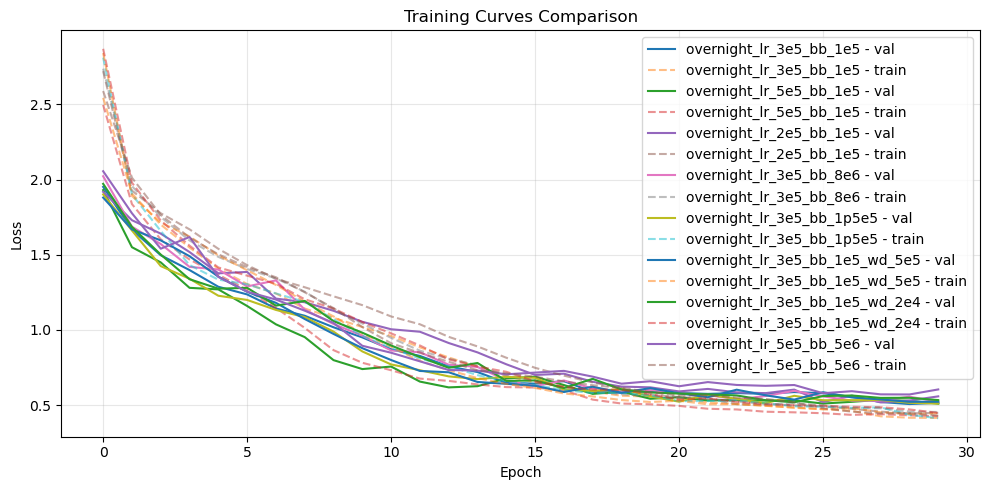

Comparacion guardada en: runs/detr_deeppcb_suite_20260322_151016/comparison_all_curves.png
Mejor run en: runs/detr_deeppcb_suite_20260322_151016/overnight_lr_3e5_bb_1e5


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for exp_name, exp_history in all_histories.items():
    plt.plot(exp_history["val_loss"], label=f"{exp_name} - val")
    plt.plot(exp_history["train_loss"], linestyle="--", alpha=0.5, label=f"{exp_name} - train")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curves Comparison")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(suite_dir / "comparison_all_curves.png", dpi=150)
plt.show()

print("Comparacion guardada en:", suite_dir / "comparison_all_curves.png")
print("Mejor run en:", save_dir)


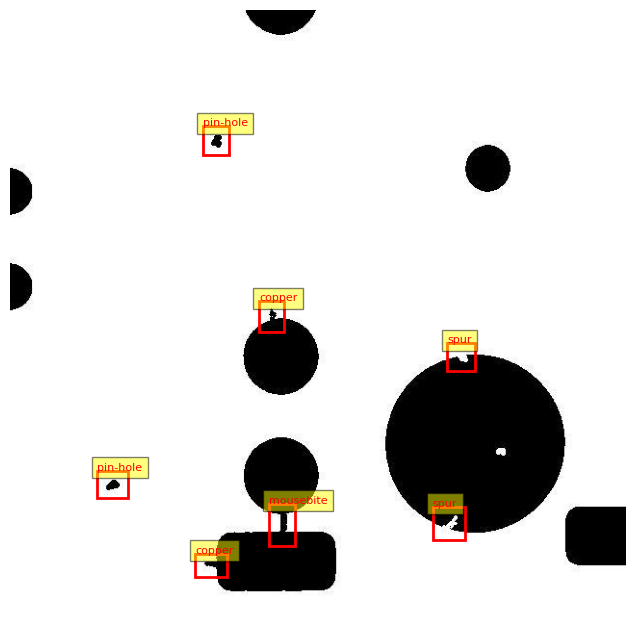

In [12]:
import torch
import matplotlib.pyplot as plt

model.eval()

# Tomar una muestra
image, target = dataset[10]

# DETR espera lista de imágenes
inputs = processor(images=[image], return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-processing correcto
results = processor.post_process_object_detection(
    outputs,
    target_sizes=[(image.size[1], image.size[0])],  # (h, w)
    threshold=0.5
)[0]

# Plot
plt.figure(figsize=(8, 8))
plt.imshow(image)

for score, label, box in zip(
    results["scores"],
    results["labels"],
    results["boxes"]
):
    xmin, ymin, xmax, ymax = box.cpu().numpy()

    plt.gca().add_patch(
        plt.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            edgecolor="red",
            linewidth=2
        )
    )

    plt.text(
        xmin,
        ymin,
        model.config.id2label[label.item()],
        color="red",
        fontsize=8,
        bbox=dict(facecolor="yellow", alpha=0.5)
    )

plt.axis("off")
plt.show()

In [13]:
import torch
import gc

# 1. Intentar borrar las variables pesadas (si te acordás los nombres)
# Por ejemplo: del model, del optimizer, del data_loader
# Si no las borrás, siguen ocupando VRAM.

# 2. Forzar la recolección de basura de Python
gc.collect()

# 3. Vaciar el caché de CUDA
torch.cuda.empty_cache()

# 4. (Opcional) Resetear estadísticas para ver la memoria real limpia
torch.cuda.reset_peak_memory_stats()


